In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import sentencepiece as spm
import os
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# --- ジャンル設定 ---
TARGET_GENRE_ID = 101
genres_map = {
    0: '未設定', 101: '異世界（恋愛）', 102: '現実世界（恋愛）',
    201: 'ハイファンタジー', 202: 'ローファンタジー',
    301: '純文学', 302: 'ヒューマンドラマ', 303: '歴史',
    304: '推理', 305: 'ホラー', 306: 'アクション', 307: 'コメディー',
    401: 'VRゲーム', 402: '宇宙', 403: '空想科学', 404: 'パニック',
    9901: '童話', 9902: '詩', 9903: 'エッセイ', 9904: 'リプレイ',
    9999: 'その他', 9801: 'ノンジャンル'
}

genre_name = genres_map.get(TARGET_GENRE_ID, 'all')
print(f"学習対象ジャンル: {genre_name} (ID: {TARGET_GENRE_ID})")

# シード値の固定
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用デバイス: {device}")

学習対象ジャンル: ノンジャンル (ID: 9801)
使用デバイス: cuda


In [2]:
# データセットの読み込み
try:
    df = pd.read_csv('dataset/narou_dataset.csv', encoding='utf-8')
except UnicodeDecodeError:
    df = pd.read_csv('dataset/narou_dataset.csv', encoding='cp932')

print(f"読み込み直後の全データ数: {len(df)}")

# --- 1. ジャンルによるフィルタリング ---
if TARGET_GENRE_ID is not None:
    # 念のため数値型に変換してから比較
    df['作品ジャンル'] = pd.to_numeric(df['作品ジャンル'], errors='coerce')
    df = df[df['作品ジャンル'] == TARGET_GENRE_ID]
    print(f"ジャンル[{genre_name}]で絞り込み後のデータ数: {len(df)}")
    
    if len(df) == 0:
        raise ValueError("該当するジャンルのデータが存在しません。TARGET_GENRE_IDを確認してください。")

# 必要なカラムのみ抽出
df = df[['あらすじ', 'is_eternal']].dropna()
df['あらすじ'] = df['あらすじ'].astype(str)

# --- 2. テキストの前処理（URL置換など） ---
def clean_text(text):
    # URLを <URL> に置換
    text = re.sub(r'https?://[\w/:%#\$&\?\(\)~\.=\+\-]+', '<URL>', text)
    # 改行コードをスペースに
    text = text.replace('\n', ' ').replace('\r', '')
    return text

df['あらすじ'] = df['あらすじ'].apply(clean_text)

# --- 3. アンダーサンプリング（データ数を揃える） ---
eternal_df = df[df['is_eternal'] == 1]
finished_df = df[df['is_eternal'] == 0]

print(f"クラス別データ数 - エタり: {len(eternal_df)}, 非エタり: {len(finished_df)}")

if len(eternal_df) == 0 or len(finished_df) == 0:
    raise ValueError("どちらかのクラスのデータが0件のため、学習できません。ジャンルを変更するかデータを確認してください。")

# 少ない方の件数を取得
min_count = min(len(eternal_df), len(finished_df))

# 少ない方に合わせてランダムサンプリング
eternal_balanced = eternal_df.sample(n=min_count, random_state=42)
finished_balanced = finished_df.sample(n=min_count, random_state=42)

# 結合してシャッフル
df_balanced = pd.concat([eternal_balanced, finished_balanced])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"サンプリング後（学習に使用するデータ） - 合計: {len(df_balanced)} (各クラス: {min_count})")

# 学習用とテスト用に分割 (8:2)
train_df, test_df = train_test_split(
    df_balanced, 
    test_size=0.2, 
    random_state=42, 
    stratify=df_balanced['is_eternal']
)

print(f"学習データ数: {len(train_df)}, テストデータ数: {len(test_df)}")

読み込み直後の全データ数: 537829
ジャンル[ノンジャンル]で絞り込み後のデータ数: 121298
クラス別データ数 - エタり: 20174, 非エタり: 101124
サンプリング後（学習に使用するデータ） - 合計: 40348 (各クラス: 20174)
学習データ数: 32278, テストデータ数: 8070


In [ ]:
# --- SentencePieceモデルの学習 ---
if TARGET_GENRE_ID is None:
    safe_name = 'all'
else:
    safe_name = str(TARGET_GENRE_ID)

corpus_filename = f'result_subword/corpus_{safe_name}.txt'
model_prefix = f'result_subword/spm_{safe_name}'

print(f"コーパスファイル名: {corpus_filename}")
print(f"モデルプレフィックス: {model_prefix}")

# 1. 学習用テキストファイルの作成
# (ここで日本語ファイル名を使わないように変更)
with open(corpus_filename, 'w', encoding='utf-8') as f:
    for text in train_df['あらすじ']:
        f.write(text + '\n')

# 2. SentencePieceの学習
# vocab_sizeの設定（念のためエラー回避ロジックを入れておきます）
vocab_size = min(30000, max(5000, int(len(train_df) * 0.5)))
print(f"設定されたvocab_size: {vocab_size}")
# データ行数がvocab_sizeより少ないとエラーになるので調整
#if len(train_df) < vocab_size:
#    vocab_size = len(train_df)
#    print(f"※データ数が少ないため、vocab_sizeを {vocab_size} に調整しました。")

spm.SentencePieceTrainer.Train(
    input=corpus_filename,      # 修正したファイル名
    model_prefix=model_prefix,  # 修正したプレフィックス
    vocab_size=vocab_size,
    character_coverage=0.9995,
    model_type='unigram',
    user_defined_symbols=['<URL>'] 
)

# 3. モデルのロード
sp = spm.SentencePieceProcessor()
sp.Load(f'{model_prefix}.model')

print(f"モデル {model_prefix}.model をロードしました。")

# テスト実行
sample_text = "詳細はこちら https://ncode.syosetu.com/xxxx/ です"
cleaned_sample = clean_text(sample_text) 
print(f"原文: {sample_text}")
print(f"前処理後: {cleaned_sample}")
print("トークン分割:", sp.EncodeAsPieces(cleaned_sample))

コーパスファイル名: result_subword/corpus_9801.txt
モデルプレフィックス: result_subword/spm_9801
設定されたvocab_size: 16139
モデル result_subword/spm_9801.model をロードしました。
原文: 詳細はこちら https://ncode.syosetu.com/xxxx/ です
前処理後: 詳細はこちら <URL> です
トークン分割: ['▁', '詳細は', 'こちら', '▁', '<URL>', '▁', 'です']


In [4]:
class NarouDataset(Dataset):
    def __init__(self, texts, labels, sp_model):
        self.texts = texts
        self.labels = labels
        self.sp_model = sp_model

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts.iloc[idx]
        label = self.labels.iloc[idx]
        token_ids = self.sp_model.EncodeAsIds(text)
        return torch.tensor(token_ids, dtype=torch.long), torch.tensor(label, dtype=torch.float)

def collate_fn(batch):
    texts, labels = zip(*batch)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)
    labels = torch.stack(labels)
    return texts_padded, labels

# データローダー作成
train_dataset = NarouDataset(train_df['あらすじ'], train_df['is_eternal'], sp)
test_dataset = NarouDataset(test_df['あらすじ'], test_df['is_eternal'], sp)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [5]:
class LSTMAttentionClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, padding_idx):
        super(LSTMAttentionClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True, bidirectional=True)
        # Attention用の層
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, text):
        embedded = self.embedding(text)
        # lstm_out: [batch, seq_len, hidden*2]
        lstm_out, _ = self.lstm(embedded)
        
        # Attentionスコアの計算
        attn_weights = torch.tanh(self.attention(lstm_out)) # [batch, seq_len, 1]
        attn_weights = torch.softmax(attn_weights, dim=1)   # 確率分布に変換
        
        # 重み付き和を計算（Context Vector）
        context = torch.sum(attn_weights * lstm_out, dim=1) # [batch, hidden*2]
        
        return self.sigmoid(self.fc(context))

VOCAB_SIZE = sp.GetPieceSize()
EMBEDDING_DIM = 100
HIDDEN_DIM = 128
OUTPUT_DIM = 1
PADDING_IDX = 0 

model = LSTMAttentionClassifier(VOCAB_SIZE, EMBEDDING_DIM, HIDDEN_DIM, OUTPUT_DIM, PADDING_IDX)
model = model.to(device)

--- 学習開始 (Early Stopping有効) ---
Epoch: 1, Train Loss: 0.6830, Val Loss: 0.6675
  -> Best Model 更新 (Val Loss: 0.6675)
Epoch: 2, Train Loss: 0.6446, Val Loss: 0.6425
  -> Best Model 更新 (Val Loss: 0.6425)
Epoch: 3, Train Loss: 0.5896, Val Loss: 0.6411
  -> Best Model 更新 (Val Loss: 0.6411)
Epoch: 4, Train Loss: 0.5273, Val Loss: 0.6746
  -> 改善なし (1/2)
Epoch: 5, Train Loss: 0.4560, Val Loss: 0.7308
  -> 改善なし (2/2)
Early Stopping: 過学習が進んでいるため学習を停止します。
--- 最良モデルをロードしました ---


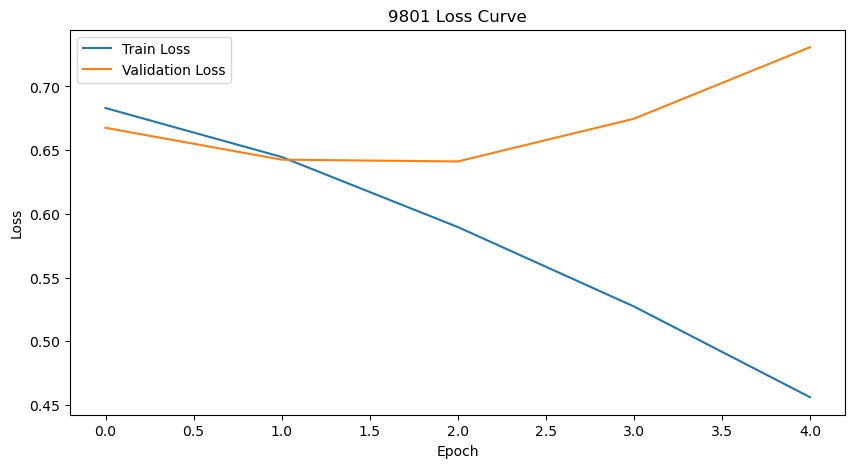

In [6]:
import copy # モデルのコピー用

# 1. Optimizerに weight_decay を追加（過学習抑制の基本）
# weight_decay=1e-5 程度を入れると、パラメータが極端な値になるのを防ぎます
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.BCELoss()

EPOCHS = 10
patience = 2  # Val Lossが3回連続で下がらなかったら強制終了

train_losses = []
val_losses = []

best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict()) # 最良モデルの保存用
no_improve_cnt = 0 # カウンタ

print(f"--- 学習開始 (Early Stopping有効) ---")

for epoch in range(EPOCHS):
    # --- 学習フェーズ ---
    model.train()
    batch_loss = 0
    for texts, labels in train_loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        predictions = model(texts).squeeze(1)
        loss = criterion(predictions, labels)
        loss.backward()
        optimizer.step()
        batch_loss += loss.item()
    
    avg_train_loss = batch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # --- 検証フェーズ ---
    model.eval()
    val_batch_loss = 0
    with torch.no_grad():
        for texts, labels in test_loader:
            texts, labels = texts.to(device), labels.to(device)
            predictions = model(texts).squeeze(1)
            loss = criterion(predictions, labels)
            val_batch_loss += loss.item()
            
    avg_val_loss = val_batch_loss / len(test_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch: {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    
    # --- Early Stopping判定 ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(model.state_dict()) # 最良モデルを記録
        no_improve_cnt = 0 # カウンタリセット
        print(f"  -> Best Model 更新 (Val Loss: {best_val_loss:.4f})")
    else:
        no_improve_cnt += 1
        print(f"  -> 改善なし ({no_improve_cnt}/{patience})")
        
        if no_improve_cnt >= patience:
            print("Early Stopping: 過学習が進んでいるため学習を停止します。")
            break

# 学習終了後、最も良かった状態の重みをモデルに戻す
model.load_state_dict(best_model_wts)
print("--- 最良モデルをロードしました ---")

# グラフ描画
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title(f'{TARGET_GENRE_ID} Loss Curve')
plt.show()

In [7]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for texts, labels in test_loader:
        texts, labels = texts.to(device), labels.to(device)
        predictions = model(texts).squeeze(1)
        
        preds = (predictions >= 0.5).long()
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print(f"---{genre_name} 評価 ---")
print(classification_report(y_true, y_pred, target_names=['非エタり', 'エタり']))

---ノンジャンル 評価 ---
              precision    recall  f1-score   support

        非エタり       0.61      0.74      0.67      4035
         エタり       0.67      0.53      0.59      4035

    accuracy                           0.64      8070
   macro avg       0.64      0.64      0.63      8070
weighted avg       0.64      0.64      0.63      8070



In [8]:
# --- train_subword.ipynb の最後に追加してください ---

import os
import torch

# 保存ディレクトリの確認
save_dir = 'result_subword'
os.makedirs(save_dir, exist_ok=True)

# ファイル名の決定（全作品かジャンル別かで分岐）
if TARGET_GENRE_ID is None:
    suffix = "all"
else:
    suffix = str(TARGET_GENRE_ID)

save_path = os.path.join(save_dir, f'model_{suffix}.pt')

# モデルの重み（state_dict）を保存
torch.save(model.state_dict(), save_path)

print(f"LSTMモデルの重みを保存しました: {save_path}")
print("※比較用コード(compare_models.ipynb)を実行する前に、このファイルが必要です。")

LSTMモデルの重みを保存しました: result_subword\model_9801.pt
※比較用コード(compare_models.ipynb)を実行する前に、このファイルが必要です。
